In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
digits = load_digits()

print("Shape of data:", digits.data.shape)
print("Shape of images:", digits.images.shape)
print("Classes:", digits.target_names)

Shape of data: (1797, 64)
Shape of images: (1797, 8, 8)
Classes: [0 1 2 3 4 5 6 7 8 9]


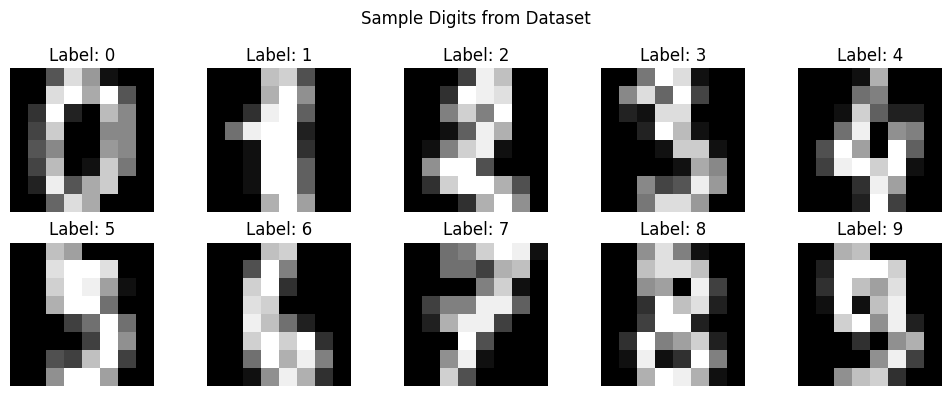

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')

plt.suptitle("Sample Digits from Dataset")
plt.tight_layout()
plt.show()

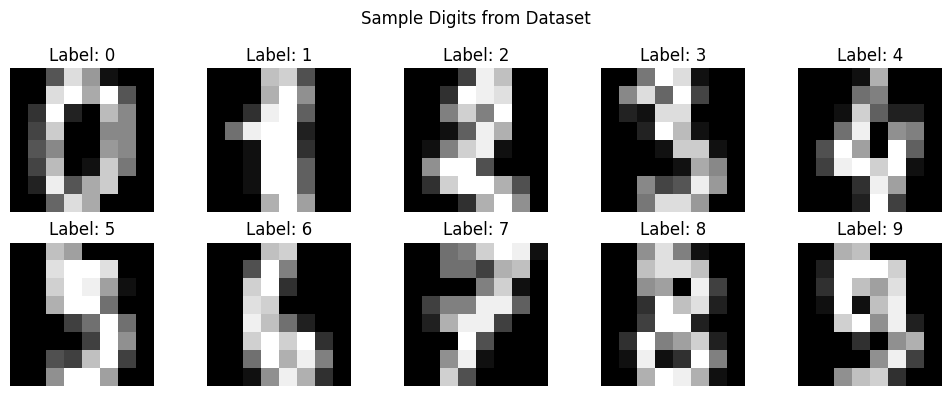

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')

plt.suptitle("Sample Digits from Dataset")
plt.tight_layout()
plt.show()

In [29]:
X = digits.data
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:\n",
      {i: list(y).count(i) for i in range(10)})

X shape: (1797, 64)
y shape: (1797,)
Class distribution:
 {0: 178, 1: 182, 2: 177, 3: 183, 4: 181, 5: 182, 6: 181, 7: 179, 8: 174, 9: 180}


In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training size:",x_train.shape)
print("Testing size:",x_test.shape)

Training size: (1437, 64)
Testing size: (360, 64)


In [31]:
accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K={k:2d}  →  Accuracy: {round(acc*100, 2)}%")

K= 1  →  Accuracy: 97.78%
K= 2  →  Accuracy: 98.06%
K= 3  →  Accuracy: 98.33%
K= 4  →  Accuracy: 98.06%
K= 5  →  Accuracy: 98.61%
K= 6  →  Accuracy: 98.89%
K= 7  →  Accuracy: 98.89%
K= 8  →  Accuracy: 98.61%
K= 9  →  Accuracy: 98.06%
K=10  →  Accuracy: 98.33%
K=11  →  Accuracy: 98.33%
K=12  →  Accuracy: 97.78%
K=13  →  Accuracy: 97.78%
K=14  →  Accuracy: 98.06%
K=15  →  Accuracy: 97.78%
K=16  →  Accuracy: 98.06%
K=17  →  Accuracy: 98.33%
K=18  →  Accuracy: 98.06%
K=19  →  Accuracy: 97.5%
K=20  →  Accuracy: 97.78%


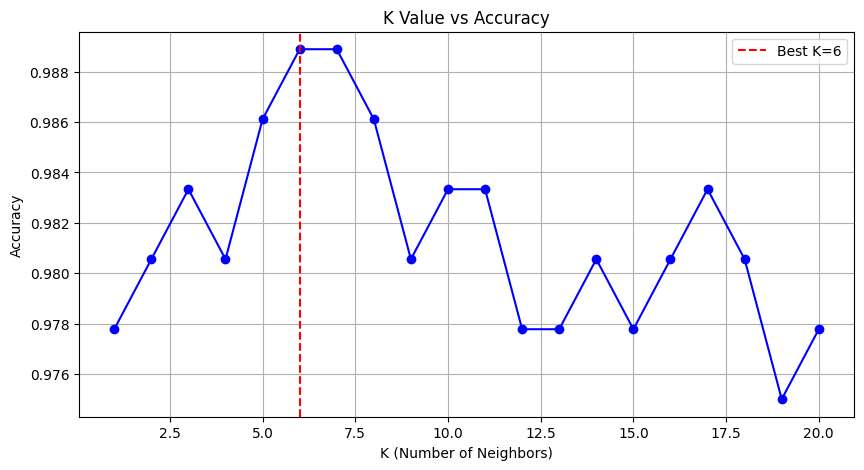

Best K: 6
Best Accuracy: 98.89 %


In [32]:
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), accuracies, 'o-', color='blue')
plt.axvline(x=accuracies.index(max(accuracies))+1,
            color='red', linestyle='--',
            label=f'Best K={accuracies.index(max(accuracies))+1}')
plt.title("K Value vs Accuracy")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("Best K:", accuracies.index(max(accuracies))+1)
print("Best Accuracy:", round(max(accuracies)*100, 2), "%")

In [33]:
param_grid = {'n_neighbors': range(1, 21)}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best K from GridSearchCV:", grid.best_params_)
print("Best Cross-Validation Accuracy:", round(grid.best_score_*100, 2), "%")

Best K from GridSearchCV: {'n_neighbors': 1}
Best Cross-Validation Accuracy: 98.61 %


In [34]:
best_k = grid.best_params_['n_neighbors']

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

y_pred_final = knn_final.predict(X_test)

print(f"Final Model with K={best_k}")
print("Accuracy:", round(accuracy_score(y_test, y_pred_final)*100, 2), "%")


Final Model with K=1
Accuracy: 97.78 %


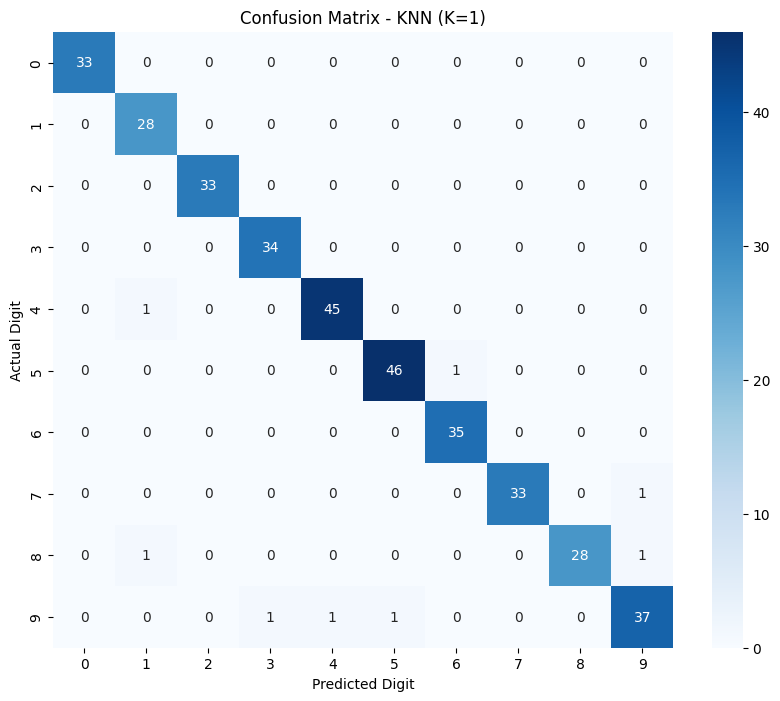

In [35]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.title(f"Confusion Matrix - KNN (K={best_k})")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()

In [36]:
report = classification_report(y_test, y_pred_final,
                                target_names=[str(i) for i in digits.target_names])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      0.98      0.98        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



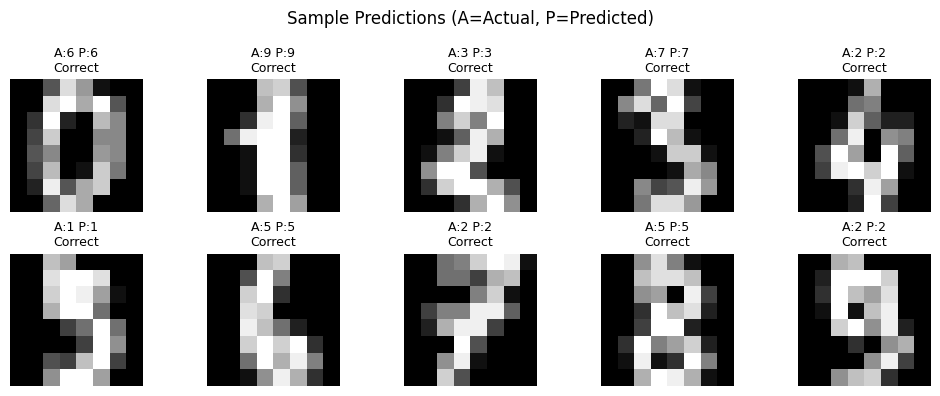

In [37]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    actual    = y_test[i]
    predicted = y_pred_final[i]
    match = "Correct" if actual == predicted else "Wrong"  # no emoji
    ax.set_title(f"A:{actual} P:{predicted}\n{match}", fontsize=9)
    ax.axis('off')

plt.suptitle("Sample Predictions (A=Actual, P=Predicted)")
plt.tight_layout()
plt.show()